# Analisis de reseñas de Dyson

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Importación de las librerias principales que vamos a utilizar para el análisis de sentimiento y topics

In [45]:
import re
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET = "tuempresa"
CAT = "sectordetuempresa"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [30]:
df_raw = pd.read_csv("trustpilot-reviews-123k.csv")
df_raw.sample(5)

,category,company,description,title,review,stars
105623,Events & Entertainment,www.funkypigeon.com,"Personalised cards & gifts for birthday, anniv...",Great customer service,Great customer service! My mug arrived broken ...,5
65564,Construction & Manufacturing,millerhomes.co.uk,Miller Homes is one of the UK's leading privat...,All Ok.,Sales experience was brilliant. Site Team are ...,3
30990,Electronics & Technology,www.partmaster.co.uk,Partmaster.co.uk is a well established busines...,The product was available,"The product was available, it was delivered on...",4
41030,Home Services,www.bensgutters.com,Professional gutter cleaning company providing...,DO NOT USE THIS COMPANY,DO NOT USE THIS COMPANY. Absolute scam. Booked...,1
15376,Hobbies & Crafts,theknittingnetwork.co.uk,"Welcome to The Knitting Network! With over 50,...",Many faults in yarn.,The yarn was knotted in one ball after I had k...,2


In [31]:
df_raw['title_review'] = df_raw['title'] + ' ' + df_raw['review']

In [32]:
df_raw.head(3)

,category,company,description,title,review,stars,title_review
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,Great quality dog drying robe although… Great ...
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5,"Really prompt service Really prompt service, T..."
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5,Life saver I’ve purchased first of those coats...


## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [33]:
# Muestra aleatoria para ver con tus propios ojos
df_raw['review'].sample(10).tolist()

["The value of this membership keeps being eroded. Lounges have closed and others now are more often than not at capacity, so you can't get in. Then those where you can get in are a crapshoot if they are air-conditioned or have decent services. ",
 "Simple template to store your filed return, complete that, upload and it's done. By using a separate sheet, your forced to create a fixed file for your records, which is genius.",
 "Otta not only delivers on providing job listings tailored to your desired role/industry, but the listings are curated AND exciting AND unique. Candidates will often find the same roles with the same companies when using other job search platforms. I'm starting a new job next week with an incredible start up company that I probably never would have come across had it not been for Otta. Highly, highly recommend.",
 "I pre-ordered a book that was limited edition with secret covers and they shipped it earlier than it came out, which surprised me because usually the 

In [34]:
# Longitud de reseñas
df_raw['review_len'] = df_raw['review'].str.len()
df_raw['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

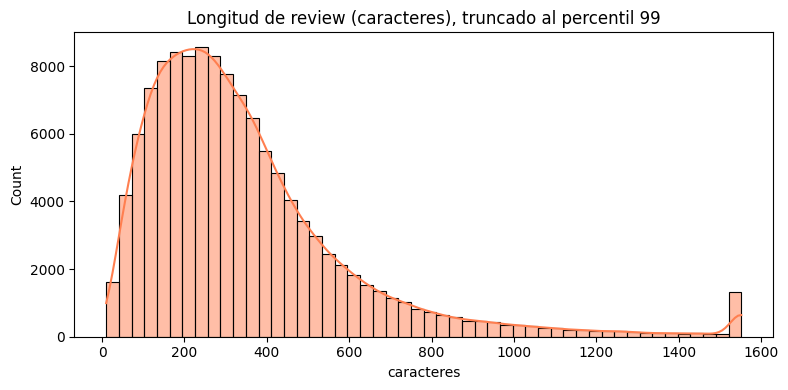

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df_raw["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [36]:
# ver que tipos de caracteres tenemos para construir la funcion de limpieza: hastags, emojis, urls, menciones, saltos de linea, signos de puntuacion, numeros, etc
def contar_caracteres(df, col):
    char_types = {
        "hashtags": r"#\w+",
        "emojis": r"[^\w\s,]",
        "urls": r"http\S+|www\S+",
        "mentions": r"@\w+",
        "line_breaks": r"\n",
        "punctuation": r"[^\w\s]",
        "numbers": r"\d+"
    }   

    char_counts = {name: df[col].str.count(pattern).sum() for name, pattern in char_types.items()}
    char_counts_df = pd.DataFrame(list(char_counts.items()), columns=['Character Type', 'Count'])
    char_counts_df.sort_values(by='Count', ascending=False, inplace=True, ignore_index=True) 

    return char_counts_df
contar_caracteres(df_raw, 'review')

,Character Type,Count
0,punctuation,1016080
1,emojis,807046
2,numbers,123910
3,hashtags,252
4,mentions,149
5,urls,15
6,line_breaks,0


## 5) Filtrado del sector de la compañía objetivo

Filtramos por sector para aplicar la limpieza y posterior tratamiento

In [37]:
# Seleccionamos la empresa y la categoría de interés
target_company = 'www.dyson.co.uk'
target_category = 'Electronics & Technology'

# Dataframe con las reseñas de todas las empresas de nuestra categoría 
df = df_raw[df_raw["category"] == target_category].copy()

# Dataframe con las empresas de la competencia
# df_comp = df_raw[(df_raw["company"] != target_company) & (df_raw["category"] == target_category)].copy()

print(df.shape)
df.head()

(5596, 8)


,category,company,description,title,review,stars,title_review,review_len
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5,Dave 55 Excellent service as always shout out ...,407
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5,Great service from Richer Sounds… Great servic...,347
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5,Wanted a TV for an 84 year old relative… Wante...,286
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS Exce...,308
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5,Purchase of Hi-Fi Equipment From Richer Sounds...,363


## 6) Construimos y aplicamos la funcion de limpieza



In [49]:
from nltk.corpus import stopwords
# Función de limpieza de texto
def limpiar_texto(texto):
    texto = re.sub(r'http\S+|www\S+', '', texto) # Elimina url
    texto = texto.replace("\n", " ")  # Eliminar saltos de línea
    texto = texto.lower() # Convierte a minúsculas
    texto = re.sub(r'[^\w\s,]', '', texto) # Elimina emojis
    texto = re.sub(r'[^\w\s]', '', texto) # Elimina caracteres especiales
    texto = re.sub(r'\d+', '', texto)  # Elimina números
    stop_words = set(stopwords.words('english'))
    texto = " ".join(word for word in texto.split() if word not in stop_words)  # Eliminar stopwords
    texto = re.sub(r'\s+', ' ', texto).strip()  # Elimina espacios múltiples
    return texto

# Función de lipieza de nombres de compñia
def limpiar_nombre(texto):
    texto = re.sub('www.', '', texto)
    texto = re.sub('.co', '', texto)
    texto = re.sub('.com', '', texto)
    texto = re.sub('.uk', '', texto)
    return texto

In [50]:
df['company_clean'] = df['company'].apply(limpiar_nombre)
df.sample(10)

,category,company,description,title,review,stars,title_review,review_len,clean,sentimiento,company_clean
31154,Electronics & Technology,www.buyspares.co.uk,Get genuine spare parts & accessories at low p...,Gas cooker knobs advertised as being…,Gas cooker knobs advertised as being suitable ...,1,Gas cooker knobs advertised as being… Gas cook...,410,gas cooker knobs advertised gas cooker knobs a...,Negativo,buyspares
33357,Electronics & Technology,www.ceiling-speakers.co.uk,\nThe Specialist Audio Company is at the foref...,Bespoke Guidance and exemplary service,I recently purchased ceiling speakers from a s...,5,Bespoke Guidance and exemplary service I recen...,817,bespoke guidance exemplary service recently pu...,Positivo,ceiling-speakers
30383,Electronics & Technology,gtech.co.uk,"Founded by inventor Nick Grey in 2001, Gtech ...",The Air Ram is a good machine but we…,The Air Ram is a good machine but we think the...,4,The Air Ram is a good machine but we… The Air ...,115,air ram good machine air ram good machine thin...,Positivo,gtech
29992,Electronics & Technology,www.yourspares.co.uk,\n\n\n\t\t\tWelcome to yourspares.co.uk!\n\n\t...,No smell smellies!,I was well satisfied with the speed of deliver...,4,No smell smellies! I was well satisfied with t...,274,smell smellies well satisfied speed delivery c...,Positivo,yourspares
33122,Electronics & Technology,bopdj.com,"Visit our Showrooms in Leeds, Bristol and Manc...",First time going to popdj in Bristol…,First time going to popdj in Bristol I’ve got ...,5,First time going to popdj in Bristol… First ti...,353,first time going popdj bristol first time goin...,Positivo,bopdjm
31473,Electronics & Technology,www.markselectrical.co.uk,You can buy from our massive range online or o...,I had the superb team of AB/BAZ who…,I had the superb team of AB/BAZ who were polit...,5,I had the superb team of AB/BAZ who… I had the...,268,superb team abbaz superb team abbaz polite eff...,Positivo,markselectrical
70227,Electronics & Technology,belling.co.uk,For over a century Belling has brought clever ...,Andrew Lao was very helpful in sorting…,Andrew Lao was very helpful in sorting out my ...,5,Andrew Lao was very helpful in sorting… Andrew...,74,andrew lao helpful sorting andrew lao helpful ...,Positivo,belling
30184,Electronics & Technology,www.vax.co.uk,Vax was founded in 1977 by British entrepreneu...,mixed feedback,Watch out for the delivery charges under £20. ...,4,mixed feedback Watch out for the delivery char...,111,mixed feedback watch delivery charges amanda c...,Positivo,vax
33857,Electronics & Technology,scgconnected.co.uk,"Established in 1965, SCG Connected\nis a suppl...",Wrong Equipment,"As happened previously, the wrong equipment go...",3,"Wrong Equipment As happened previously, the wr...",199,wrong equipment happened previously wrong equi...,Negativo,scnnected
33134,Electronics & Technology,bopdj.com,"Visit our Showrooms in Leeds, Bristol and Manc...",Got the product I wanted,"Got the product I wanted , but it was 1 week l...",4,Got the product I wanted Got the product I wan...,226,got product wanted got product wanted week lat...,Positivo,bopdjm


In [42]:
df['clean'] = df['title_review'].apply(limpiar_texto)
contar_caracteres(df, 'clean')

,Character Type,Count
0,emojis,16
1,punctuation,16
2,hashtags,0
3,urls,0
4,mentions,0
5,line_breaks,0
6,numbers,0


In [43]:
df['clean'].sample(10).tolist()

['ive loyal consistent ive loyal consistent customer jessops never let always chose shop herebut time around may changed mind ordered week ago parcel still arrivedive lost gigs due specially busy season whenever speak customer service get told arrive today tomorrow past days',
 'ordered christmas present said ordered christmas present said stock month ago cancelled delivery dates christmas present wife christmas still present good service',
 'one thing edit sds one thing edit sds battery cover saying bt battery',
 'product gb memory product gb memory advertised website performs properly advertised price reasonable delivery duration specified',
 'sales issues sales issues faulty goods one willing take ownership replacement goods arranged afternoon new years eve whilst delivery drivers work noon day frustrating experience many hours spent phone trying resolve simple issue',
 'love binocular harness lce great customer service reasonable prices understand need delivery signature struggle r

## 7) Sentimiento
Construimos y aplicamos el análisis de sentimiento para incluir una columna binaria de sentimiento: positivo o negativo.


In [44]:
# Cargar el modelo y el tokenizador preentrenado para Sentiment Analysis
modelo = AutoModelForSequenceClassification.from_pretrained(
    "nlptown/bert-base-multilingual-uncased-sentiment"
)
tokenizer = AutoTokenizer.from_pretrained(
    "nlptown/bert-base-multilingual-uncased-sentiment"
)

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    tokens = tokenizer(texto, return_tensors="pt", padding=True, truncation=True)
    salida = modelo(**tokens)
    pred = torch.nn.functional.softmax(salida.logits, dim=-1)[0]

    etiquetas = ["Muy Negativo", "Negativo", "Neutral", "Positivo", "Muy Positivo"]
    sentimiento = etiquetas[pred.argmax().item()]
    sentimiento_bin = 'Negativo' if sentimiento in ['Muy Negativo', 'Negativo'] else 'Positivo'

    return sentimiento_bin

df['sentimiento'] = df['clean'].apply(analizar_sentimiento)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3410.22it/s]


In [46]:
df.head()

,category,company,description,title,review,stars,title_review,review_len,clean,sentimiento
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5,Dave 55 Excellent service as always shout out ...,407,dave excellent service always shout jerome bro...,Positivo
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5,Great service from Richer Sounds… Great servic...,347,great service richer sounds great service rich...,Positivo
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5,Wanted a TV for an 84 year old relative… Wante...,286,wanted tv year old relative wanted tv year old...,Positivo
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS Exce...,308,imformed friendly help richer sounds excellent...,Positivo
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5,Purchase of Hi-Fi Equipment From Richer Sounds...,363,purchase hifi equipment richer sounds sales as...,Positivo


In [48]:
# Separamos el dataframe en la empresa objetivo y competencia
df_dyson = df[df['company'] == target_company].copy()
df_competencia = df[df['company'] != target_company].copy()

# Calcular porcentajes de sentimiento
dyson_counts = df_dyson['sentimiento'].value_counts(normalize=True) * 100
comp_counts = df_competencia['sentimiento'].value_counts(normalize=True) * 100

# DataFrame para el gráfico
data_grafico = pd.DataFrame({
    'Empresa': ['Dyson', 'Competencia'],
    'Positivo': [dyson_counts.get('Positivo', 0), comp_counts.get('Positivo', 0)],
    'Negativo': [dyson_counts.get('Negativo', 0), comp_counts.get('Negativo', 0)]
})

# Gráfico de barras horizontales apiladas
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    y=data_grafico['Empresa'],
    x=data_grafico['Positivo'],
    name='Positivo',
    orientation='h',
    marker=dict(color='#2ecc71'),
    text=[f"{val:.1f}%" for val in data_grafico['Positivo']],
    textposition='inside',
    textfont=dict(color='white', size=12)
))

fig.add_trace(go.Bar(
    y=data_grafico['Empresa'],
    x=data_grafico['Negativo'],
    name='Negativo',
    orientation='h',
    marker=dict(color='#e74c3c'),
    text=[f"{val:.1f}%" for val in data_grafico['Negativo']],
    textposition='inside',
    textfont=dict(color='white', size=12)
))

fig.update_layout(
    barmode='stack',
    title='Análisis de Sentimiento: Dyson vs Competencia',
    xaxis_title='Porcentaje sentimiento (%)',
    yaxis_title='Empresa',
    hovermode='x unified',
    width=800,
    height=400
)

fig.show()

    Empresa  Positivo  Negativo
      Dyson 28.000000 72.000000
Competencia 45.469432 54.530568


## 8) Topics



In [64]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=10, min_samples=10)  # Aumentar estos valores

# *TOPICS DYSON
# Crear el modelo de tópicos
topic_model_dyson = BERTopic(language="multilingual", nr_topics=10, hdbscan_model=hdbscan_model)

# Ajustar el modelo sobre reseñas limpias
topics, probs = topic_model_dyson.fit_transform(df_dyson["clean"])

# Añadir los resultados al DataFrame original
df_dyson["topic"] = topics
df_dyson["topic_prob"] = probs

# 4. Crear un DataFrame solo para ver temas por titulo
df_topics_dyson = df_dyson[["title", "topic"]].sort_values("topic")


# *TOPICS COMPETENCIA
# Crear el modelo de tópicos
topic_model_comp = BERTopic(language="multilingual", nr_topics=10, hdbscan_model=hdbscan_model)

# Ajustar el modelo sobre reseñas limpias
topics, probs = topic_model_comp.fit_transform(df_competencia["clean"])

# Añadir los resultados al DataFrame original
df_competencia["topic"] = topics
df_competencia["topic_prob"] = probs

# 4. Crear un DataFrame solo para ver temas por titulo
df_topics_competencia = df_competencia[["title", "topic"]].sort_values("topic")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6310.09it/s]


In [77]:
df_dyson.head()

,category,company,description,title,review,stars,title_review,review_len,clean,sentimiento,topic,topic_prob
31360,Electronics & Technology,www.dyson.co.uk,\n\n\n\n Shop deals\n\n\n\n\n\n Find a store\n...,My Amazing Dyson Experience,My Amazing Dyson Experience: Above and Beyond ...,5,My Amazing Dyson Experience My Amazing Dyson E...,1178,amazing dyson experience amazing dyson experie...,Positivo,-1,0.000000
31361,Electronics & Technology,www.dyson.co.uk,\n\n\n\n Shop deals\n\n\n\n\n\n Find a store\n...,Recently I had an issue with my Dyson…,"Recently I had an issue with my Dyson v15, aft...",5,Recently I had an issue with my Dyson… Recentl...,213,recently issue dyson recently issue dyson v lo...,Positivo,0,1.000000
31362,Electronics & Technology,www.dyson.co.uk,\n\n\n\n Shop deals\n\n\n\n\n\n Find a store\n...,Great,I have hair dryer ( more than 5 y) still fully...,5,Great I have hair dryer ( more than 5 y) still...,179,great hair dryer still fully working air wrap ...,Positivo,-1,0.000000
31363,Electronics & Technology,www.dyson.co.uk,\n\n\n\n Shop deals\n\n\n\n\n\n Find a store\n...,I was greatly impressed by professionalism,I was greatly impressed by the support receive...,5,I was greatly impressed by professionalism I w...,150,greatly impressed professionalism greatly impr...,Positivo,0,0.951391
31364,Electronics & Technology,www.dyson.co.uk,\n\n\n\n Shop deals\n\n\n\n\n\n Find a store\n...,We've had Dyson Vacuums for over 10…,We've had Dyson Vacuums for over 10 years and ...,5,We've had Dyson Vacuums for over 10… We've had...,484,weve dyson vacuums weve dyson vacuums years al...,Positivo,1,1.000000


## Análisis de topics de dyson

In [65]:
conteo_topics = df_topics_dyson.groupby("topic")["title"].count()
print(conteo_topics)

topic
-1    52
 0    23
 1    25
Name: title, dtype: int64


In [67]:
topic_model_dyson.visualize_hierarchy()

In [68]:
topic_model_dyson.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,52,-1_dyson_service_customer_new,"[dyson, service, customer, new, part, would, d...",[poor vaccum appalling customer service bought...
1,0,23,0_dyson_customer_service_time,"[dyson, customer, service, time, delivery, get...",[shamefull probably worst customer service eve...
2,1,25,1_dyson_battery_cleaner_vacuum,"[dyson, battery, cleaner, vacuum, parts, new, ...",[excellent product dyson v excellent product d...


In [69]:
# Obtener todos los temas identificados
all_topics = topic_model_dyson.get_topics()

# Convertir los temas en un DataFrame asegurando estructura correcta
df_topics_info_dyson = pd.DataFrame.from_dict(all_topics, orient="index")

# Agregar el conteo de canciones por tema
df_topics_info_dyson["Cantidad de reviews"] = conteo_topics

df_topics_info_dyson

,0,1,2,3,4,5,6,7,8,9,Cantidad de reviews
-1,"(dyson, 0.08695690270173542)","(service, 0.049947578698796104)","(customer, 0.04149042363248271)","(new, 0.034117627296266016)","(part, 0.03324504789711168)","(would, 0.03238071546235049)","(days, 0.030095607778457302)","(product, 0.028922308105266865)","(experience, 0.027373044276204555)","(problem, 0.026508897607562636)",52
0,"(dyson, 0.07883182666252307)","(customer, 0.07373468087877204)","(service, 0.07277235843836909)","(time, 0.043841453049302835)","(delivery, 0.04348640409590223)","(get, 0.03741999140414596)","(call, 0.03696589507921462)","(phone, 0.03340291037616009)","(poor, 0.03188632347663007)","(order, 0.02922754657914008)",23
1,"(dyson, 0.11642659290421922)","(battery, 0.06688064950151817)","(cleaner, 0.05173732471820974)","(vacuum, 0.044831751484770505)","(parts, 0.038864143745444564)","(new, 0.036776343297281334)","(great, 0.035407402677274324)","(would, 0.034904077523155275)","(years, 0.03464490038957436)","(repair, 0.03306317297837384)",25


-1
('dyson', 0.08695690270173542) ('service', 0.049947578698796104) ('customer', 0.04149042363248271) ('new', 0.034117627296266016) ('part', 0.03324504789711168) ('would', 0.03238071546235049) ('days', 0.030095607778457302) ('product', 0.028922308105266865) ('experience', 0.027373044276204555) ('problem', 0.026508897607562636)


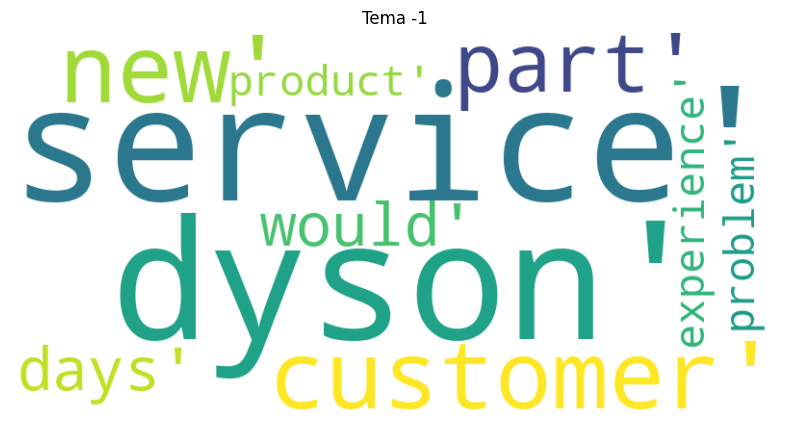

0
('dyson', 0.07883182666252307) ('customer', 0.07373468087877204) ('service', 0.07277235843836909) ('time', 0.043841453049302835) ('delivery', 0.04348640409590223) ('get', 0.03741999140414596) ('call', 0.03696589507921462) ('phone', 0.03340291037616009) ('poor', 0.03188632347663007) ('order', 0.02922754657914008)


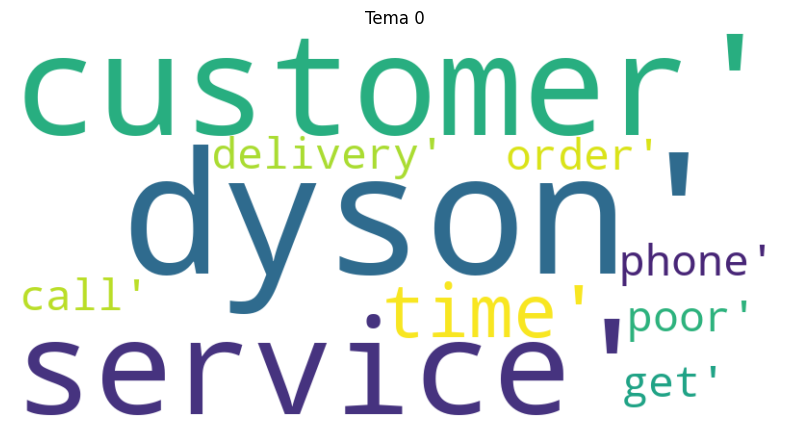

1
('dyson', 0.11642659290421922) ('battery', 0.06688064950151817) ('cleaner', 0.05173732471820974) ('vacuum', 0.044831751484770505) ('parts', 0.038864143745444564) ('new', 0.036776343297281334) ('great', 0.035407402677274324) ('would', 0.034904077523155275) ('years', 0.03464490038957436) ('repair', 0.03306317297837384)


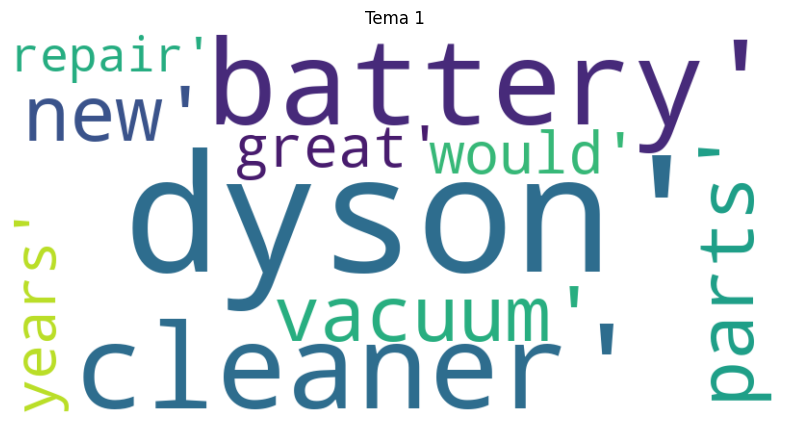

In [70]:
from wordcloud import WordCloud

# Generar un WordCloud por cada tema
for topic_num in df_topics_info_dyson.index:  # Iterar sobre cada tema
    print(topic_num)
    palabras = " ".join([str(word) for word in df_topics_info_dyson.loc[topic_num, :9]])
    print(palabras)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(palabras)

    # Mostrar la imagen
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Tema {topic_num}")
    plt.show()

## Analisis topics competencia

In [71]:
conteo_topics = df_topics_competencia.groupby("topic")["title"].count()
print(conteo_topics)

topic
-1    2035
 0    1474
 1     769
 2     454
 3     306
 4     189
 5     106
 6      84
 7      63
 8      16
Name: title, dtype: int64


In [72]:
topic_model_comp.visualize_topics()

In [73]:
topic_model_comp.visualize_hierarchy()

In [74]:
topic_model_comp.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2035,-1_service_delivery_customer_good,"[service, delivery, customer, good, would, tim...",[avoid really poor customer service really poo...
1,0,1474,0_delivery_service_order_good,"[delivery, service, order, good, item, would, ...",[still waiting weeks part order still yet arri...
2,1,769,1_fridge_machine_cooker_delivery,"[fridge, machine, cooker, delivery, washing, o...",[good fridge company would recommend subcold f...
3,2,454,2_battery_phone_offer_iphone,"[battery, phone, offer, iphone, price, good, c...",[never buy company never buy company brought b...
4,3,306,3_tv_camera_good_service,"[tv, camera, good, service, headset, speakers,...",[well got broken tv first well got broken tv f...
5,4,189,4_key_microsoft_laptop_office,"[key, microsoft, laptop, office, software, mem...",[key purchased key purchased microsoft office ...
6,5,106,5_shark_hair_ghd_straighteners,"[shark, hair, ghd, straighteners, vacuum, hair...",[bought ghd platinum plus hair bought ghd plat...
7,6,84,6_books_perlego_app_reading,"[books, perlego, app, reading, book, read, tex...",[perlego amazing app perlego amazing app reall...
8,7,63,7_video_videos_synthesia_avatar,"[video, videos, synthesia, avatar, avatars, cr...",[love easy platform synthesis platform easy us...
9,8,16,8_date_experience_august_july,"[date, experience, august, july, good, service...","[great service prompt date experience august, ..."


In [75]:
# Obtener todos los temas identificados
all_topics = topic_model_comp.get_topics()

# Convertir los temas en un DataFrame asegurando estructura correcta
df_topics_info_competencia = pd.DataFrame.from_dict(all_topics, orient="index")

# Agregar el conteo de canciones por tema
df_topics_info_competencia["Cantidad de reviews"] = conteo_topics

df_topics_info_competencia

,0,1,2,3,4,5,6,7,8,9,Cantidad de reviews
-1,"(service, 0.029467124917121536)","(delivery, 0.02931361496753286)","(customer, 0.022603165582980294)","(good, 0.022238292254669872)","(would, 0.02064470095690182)","(time, 0.018275068173444403)","(order, 0.017572078235094685)","(day, 0.0174059463077439)","(ordered, 0.017361098179195317)","(company, 0.0171628028823402)",2035
0,"(delivery, 0.038806928664134724)","(service, 0.03864823281258389)","(order, 0.028570263188596436)","(good, 0.02359518967590665)","(item, 0.022272962530542836)","(would, 0.021809970419418335)","(customer, 0.021195804885967277)","(great, 0.020518301479158497)","(company, 0.01975965800616621)","(time, 0.01961403035249457)",1474
1,"(fridge, 0.03449171387604392)","(machine, 0.027688429805312303)","(cooker, 0.02297087679854174)","(delivery, 0.02273738452265768)","(washing, 0.022554447703985077)","(oven, 0.02239279716059882)","(would, 0.02130377980283594)","(one, 0.020964041756149944)","(new, 0.020447151451949513)","(freezer, 0.018758336900584923)",769
2,"(battery, 0.07922627917871668)","(phone, 0.06904016502650684)","(offer, 0.028834683273903754)","(iphone, 0.028533665035669266)","(price, 0.025985696964053256)","(good, 0.023714575850410414)","(condition, 0.023143885372270027)","(would, 0.022459423356873762)","(batteries, 0.0224090243077813)","(sent, 0.021973163164327607)",454
3,"(tv, 0.05644613991765599)","(camera, 0.04681983337004304)","(good, 0.028864337541524423)","(service, 0.028729670101086315)","(headset, 0.02862384695824507)","(speakers, 0.02831649244666022)","(great, 0.026576379534430053)","(would, 0.026546896580162634)","(lens, 0.02512982840468283)","(delivery, 0.02501518538655928)",306
4,"(key, 0.06014451302860061)","(microsoft, 0.05303116685411395)","(laptop, 0.050963798786940524)","(office, 0.05081914240826761)","(software, 0.04721224994600017)","(memory, 0.045231767532155076)","(windows, 0.03696038811796663)","(product, 0.034655886537305496)","(keys, 0.03227789576778149)","(ssd, 0.029850713104959292)",189
5,"(shark, 0.10446098046761505)","(hair, 0.09418706203969604)","(ghd, 0.0930190956487185)","(straighteners, 0.04434094994187914)","(vacuum, 0.0331302703864796)","(hairdryer, 0.03190834543834001)","(brush, 0.031266365025117884)","(customer, 0.025893957917339255)","(product, 0.025679096935809824)","(new, 0.025143097123634214)",106
6,"(books, 0.14464176098973097)","(perlego, 0.1002607642410915)","(app, 0.07522121497865679)","(reading, 0.06146385283931912)","(book, 0.060399640071174016)","(read, 0.04712720095850574)","(text, 0.042339237088219545)","(great, 0.041688390393398396)","(page, 0.04045476376379648)","(access, 0.032720169782094556)",84
7,"(video, 0.09898449448832423)","(videos, 0.08517497921657663)","(synthesia, 0.06532219534752572)","(avatar, 0.05870340586863221)","(avatars, 0.046202262092166095)","(create, 0.04593587144027571)","(ai, 0.041581579156947816)","(content, 0.038192928710430035)","(tool, 0.03505993223900323)","(program, 0.03424365342336879)",63
8,"(date, 0.603993643798862)","(experience, 0.4472175909388581)","(august, 0.2953157258080538)","(july, 0.1718675719576757)","(good, 0.14937496808954165)","(service, 0.12831119785275658)","(generally, 0.1091606248603546)","(january, 0.10804151257971412)","(au, 0.08286464836053535)","(brillant, 0.08286464836053535)",16


-1
('service', 0.029467124917121536) ('delivery', 0.02931361496753286) ('customer', 0.022603165582980294) ('good', 0.022238292254669872) ('would', 0.02064470095690182) ('time', 0.018275068173444403) ('order', 0.017572078235094685) ('day', 0.0174059463077439) ('ordered', 0.017361098179195317) ('company', 0.0171628028823402)


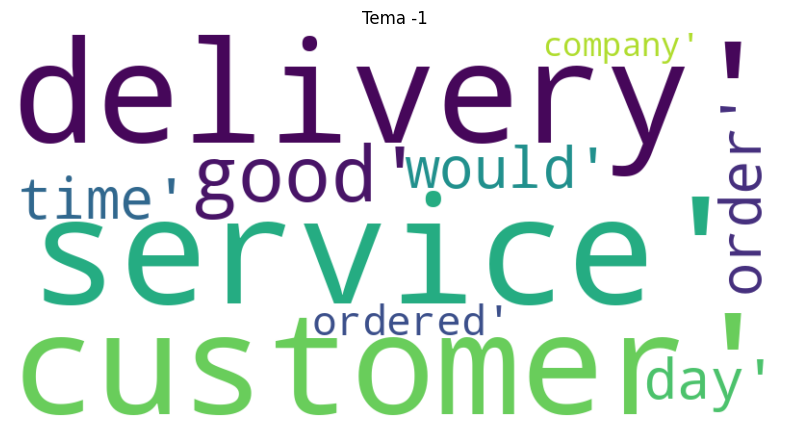

0
('delivery', 0.038806928664134724) ('service', 0.03864823281258389) ('order', 0.028570263188596436) ('good', 0.02359518967590665) ('item', 0.022272962530542836) ('would', 0.021809970419418335) ('customer', 0.021195804885967277) ('great', 0.020518301479158497) ('company', 0.01975965800616621) ('time', 0.01961403035249457)


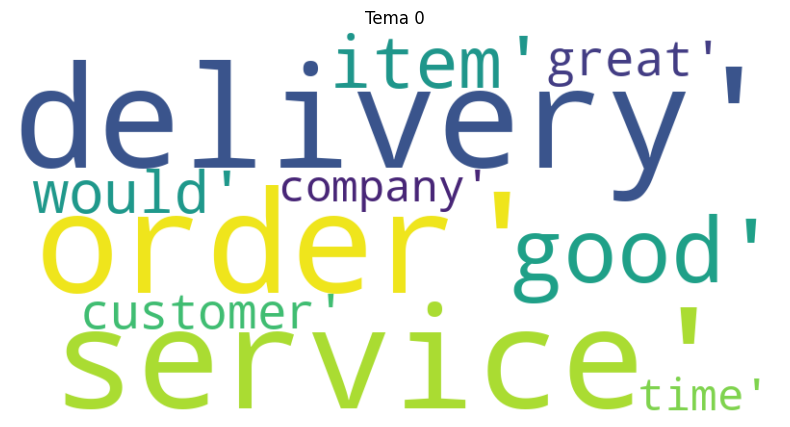

1
('fridge', 0.03449171387604392) ('machine', 0.027688429805312303) ('cooker', 0.02297087679854174) ('delivery', 0.02273738452265768) ('washing', 0.022554447703985077) ('oven', 0.02239279716059882) ('would', 0.02130377980283594) ('one', 0.020964041756149944) ('new', 0.020447151451949513) ('freezer', 0.018758336900584923)


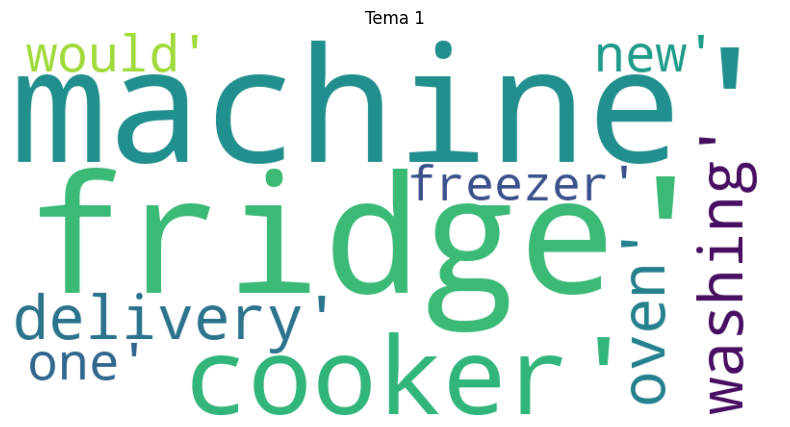

2
('battery', 0.07922627917871668) ('phone', 0.06904016502650684) ('offer', 0.028834683273903754) ('iphone', 0.028533665035669266) ('price', 0.025985696964053256) ('good', 0.023714575850410414) ('condition', 0.023143885372270027) ('would', 0.022459423356873762) ('batteries', 0.0224090243077813) ('sent', 0.021973163164327607)


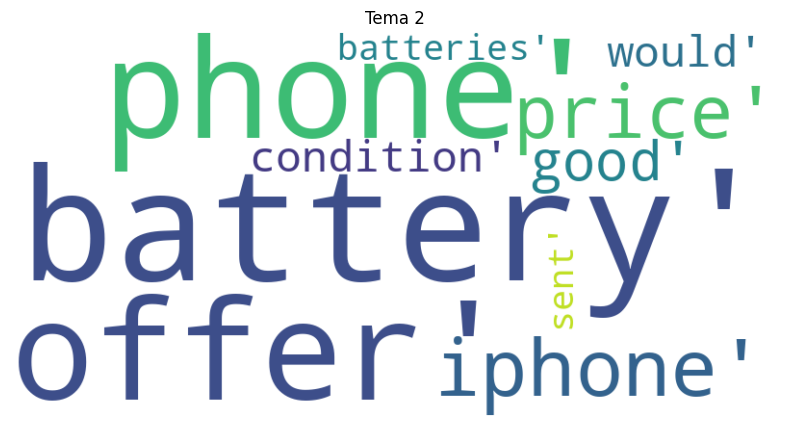

3
('tv', 0.05644613991765599) ('camera', 0.04681983337004304) ('good', 0.028864337541524423) ('service', 0.028729670101086315) ('headset', 0.02862384695824507) ('speakers', 0.02831649244666022) ('great', 0.026576379534430053) ('would', 0.026546896580162634) ('lens', 0.02512982840468283) ('delivery', 0.02501518538655928)


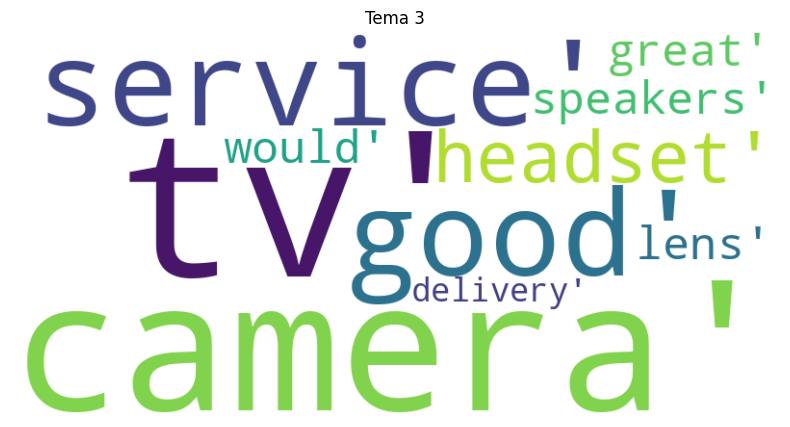

4
('key', 0.06014451302860061) ('microsoft', 0.05303116685411395) ('laptop', 0.050963798786940524) ('office', 0.05081914240826761) ('software', 0.04721224994600017) ('memory', 0.045231767532155076) ('windows', 0.03696038811796663) ('product', 0.034655886537305496) ('keys', 0.03227789576778149) ('ssd', 0.029850713104959292)


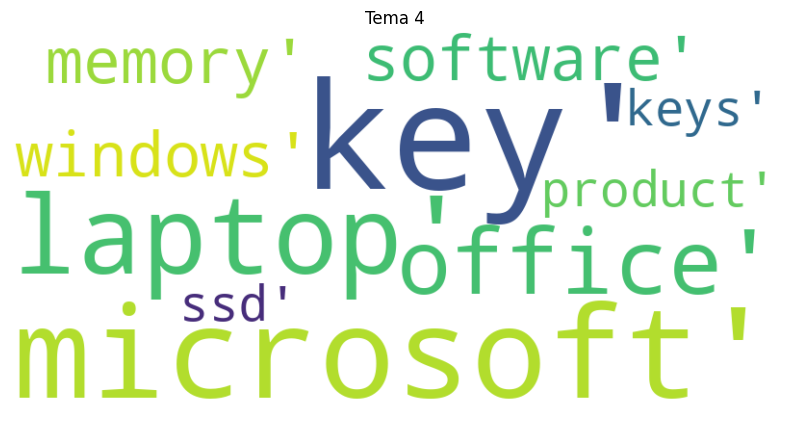

5
('shark', 0.10446098046761505) ('hair', 0.09418706203969604) ('ghd', 0.0930190956487185) ('straighteners', 0.04434094994187914) ('vacuum', 0.0331302703864796) ('hairdryer', 0.03190834543834001) ('brush', 0.031266365025117884) ('customer', 0.025893957917339255) ('product', 0.025679096935809824) ('new', 0.025143097123634214)


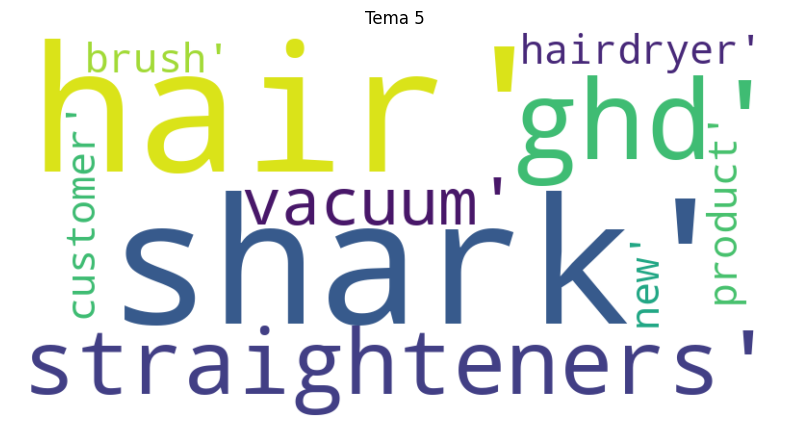

6
('books', 0.14464176098973097) ('perlego', 0.1002607642410915) ('app', 0.07522121497865679) ('reading', 0.06146385283931912) ('book', 0.060399640071174016) ('read', 0.04712720095850574) ('text', 0.042339237088219545) ('great', 0.041688390393398396) ('page', 0.04045476376379648) ('access', 0.032720169782094556)


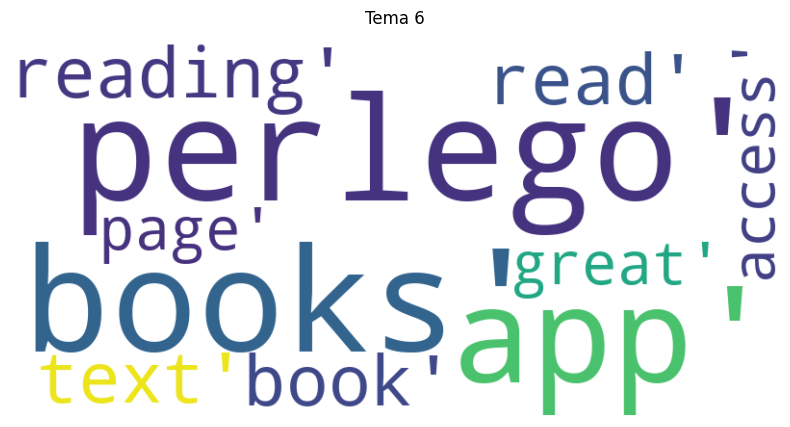

7
('video', 0.09898449448832423) ('videos', 0.08517497921657663) ('synthesia', 0.06532219534752572) ('avatar', 0.05870340586863221) ('avatars', 0.046202262092166095) ('create', 0.04593587144027571) ('ai', 0.041581579156947816) ('content', 0.038192928710430035) ('tool', 0.03505993223900323) ('program', 0.03424365342336879)


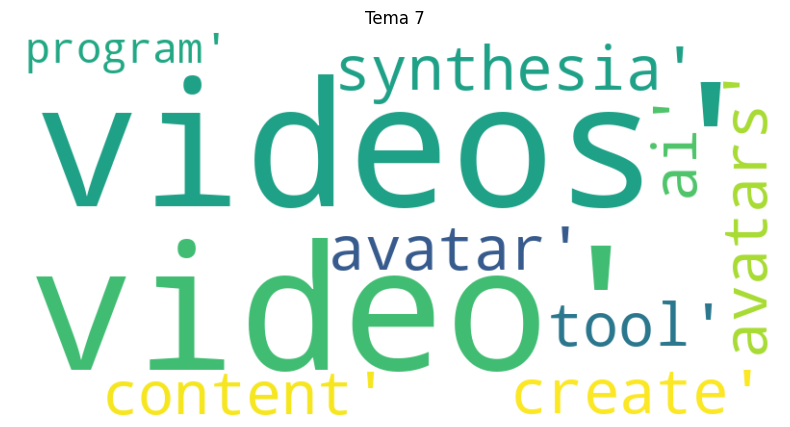

8
('date', 0.603993643798862) ('experience', 0.4472175909388581) ('august', 0.2953157258080538) ('july', 0.1718675719576757) ('good', 0.14937496808954165) ('service', 0.12831119785275658) ('generally', 0.1091606248603546) ('january', 0.10804151257971412) ('au', 0.08286464836053535) ('brillant', 0.08286464836053535)


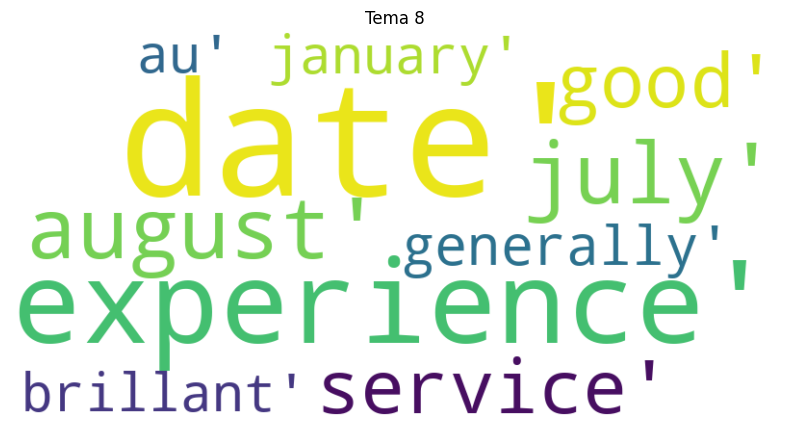

In [76]:
from wordcloud import WordCloud

# Generar un WordCloud por cada tema
for topic_num in df_topics_info_competencia.index:  # Iterar sobre cada tema
    print(topic_num)
    palabras = " ".join([str(word) for word in df_topics_info_competencia.loc[topic_num, :9]])
    print(palabras)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(palabras)

    # Mostrar la imagen
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Tema {topic_num}")
    plt.show()

## Conclusiones del análsis de topics para las empresas de la categoría 'Electronics & Tecnology'

Cuando analizamos las reseñas de Dyson vemos que hay dos topics diferenciados: 
- Servicio de atención al cliente
- Producto

Al analizar el global del resto de compañías surgen más grupos pero que también podemos agrupar en estas dos categorías, pues cada empresa tiene un tipo de producto y el modelo identifica cada producto distinto como un topic diferente. 

### Estrategia

- Vamos a agrupar las reviews en dos categorías: Servicio y Producto
- Compararemos las reviews positivas y negatias para estas dos categorías

In [78]:
# creamos nueva columa 'topic_category'
df_dyson['topic_category'] = df_dyson['topic'].map({
    -1: 'Servicio',
    0: 'Servicio',
    1: 'Producto'
})


df_competencia['topic_category'] = df_competencia['topic'].map({
    -1: 'Servicio',
    0: 'Servicio',
    1: 'Producto',
    2: 'Producto',
    3: 'Producto',
    4: 'Producto',
    5: 'Producto',
    6: 'Producto',
    7: 'Producto',
    8: 'Producto'
})

# 9) Visualizaciones

In [79]:
# Grafico de barras grupadas de porcentaje de reviews por 'topic_category' para Dyson y competencia

# Calcular porcentajes de topic_category
dyson_topic_pct = df_dyson['topic_category'].value_counts(normalize=True) * 100
comp_topic_pct = df_competencia['topic_category'].value_counts(normalize=True) * 100

# Crear DataFrame para el gráfico
data_grafico_topics = pd.DataFrame({
    'Dyson': [dyson_topic_pct.get('Servicio', 0), dyson_topic_pct.get('Producto', 0)],
    'Competencia': [comp_topic_pct.get('Servicio', 0), comp_topic_pct.get('Producto', 0)]
}, index=['Servicio', 'Producto'])

# Crear gráfico de barras verticales agrupadas
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=['Servicio', 'Producto'],
    y=data_grafico_topics['Dyson'],
    name='Dyson',
    marker=dict(color='#3498db'),
    text=[f"{val:.1f}%" for val in data_grafico_topics['Dyson']],
    textposition='outside',
    textfont=dict(size=11)
))

fig.add_trace(go.Bar(
    x=['Servicio', 'Producto'],
    y=data_grafico_topics['Competencia'],
    name='Competencia',
    marker=dict(color='#e74c3c'),
    text=[f"{val:.1f}%" for val in data_grafico_topics['Competencia']],
    textposition='outside',
    textfont=dict(size=11)
))

fig.update_layout(
    barmode='group',
    title='Porcentaje de Reviews por Categoría de Topic: Dyson vs Competencia',
    xaxis_title='Categoría de Topic',
    yaxis_title='Porcentaje (%)',
    hovermode='x unified',
    width=900,
    height=500,
    showlegend=True
)

fig.show()

In [85]:
# Grafico de barras horizontales: apiladas por sentimiento (Positivo/Negativo)
# y agrupadas por topic_category (Servicio/Producto), segmentadas por Dyson vs competencia

import plotly.graph_objects as go


def pct_sentimiento_por_topic(df, empresa_label):
    """Calcula el % de Positivo/Negativo dentro de cada topic_category."""
    tmp = (
        df.groupby('topic_category')['sentimiento']
        .value_counts(normalize=True)
        .mul(100)
        .rename('pct')
        .reset_index()
    )
    tmp['empresa'] = empresa_label
    return tmp


# Unimos Dyson y competencia en un solo DataFrame
df_pct = pd.concat([
    pct_sentimiento_por_topic(df_dyson, 'Dyson'),
    pct_sentimiento_por_topic(df_competencia, 'Competencia')
], ignore_index=True)

# Pivotamos para tener 'Positivo' y 'Negativo' como columnas
df_pivot = df_pct.pivot_table(
    index=['topic_category', 'empresa'],
    columns='sentimiento',
    values='pct',
    fill_value=0
).reset_index()

# Orden deseado en el grafico: Servicio antes que Producto, Dyson antes que Competencia
orden_topic = ['Servicio', 'Producto']
orden_empresa = ['Dyson', 'Competencia']

df_pivot['topic_category'] = pd.Categorical(df_pivot['topic_category'], categories=orden_topic, ordered=True)
df_pivot['empresa'] = pd.Categorical(df_pivot['empresa'], categories=orden_empresa, ordered=True)
df_pivot = df_pivot.sort_values(['topic_category', 'empresa']).reset_index(drop=True)

# Eje y multi-categoria: agrupa por topic_category y, dentro de cada grupo, por empresa
y_topic = df_pivot['topic_category'].astype(str).tolist()
y_empresa = df_pivot['empresa'].astype(str).tolist()

fig = go.Figure()

fig.add_trace(go.Bar(
    y=[y_topic, y_empresa],
    x=df_pivot['Positivo'],
    name='Positivo',
    orientation='h',
    marker=dict(color='#2ecc71'),
    text=[f"{val:.1f}%" for val in df_pivot['Positivo']],
    textposition='inside',
    textfont=dict(color='white', size=12)
))

fig.add_trace(go.Bar(
    y=[y_topic, y_empresa],
    x=df_pivot['Negativo'],
    name='Negativo',
    orientation='h',
    marker=dict(color='#e74c3c'),
    text=[f"{val:.1f}%" for val in df_pivot['Negativo']],
    textposition='inside',
    textfont=dict(color='white', size=12)
))

fig.update_layout(
    barmode='stack',
    title='Sentimiento por Categoria de Topic: Dyson vs Competencia',
    xaxis_title='Porcentaje sentimiento (%)',
    yaxis_title='',
    legend_title='Sentimiento',
    hovermode='y unified',
    width=900,
    height=500
)

fig.show()